In [ ]:
from google.colab import files
uploaded = files.upload()


Saving realistic_kraljic_dataset.csv to realistic_kraljic_dataset.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("realistic_kraljic_dataset.csv")
df.head()


,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic


In [ ]:
X = df.drop(["Kraljic_Category", "Product_ID", "Product_Name", "Supplier_Region"], axis=1)
y = df["Kraljic_Category"]

# Convert 'Single_Source_Risk' to numerical (e.g., 0 for 'No', 1 for 'Yes')
X['Single_Source_Risk'] = X['Single_Source_Risk'].map({'No': 0, 'Yes': 1})

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(1000, 7)
(1000,)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.96


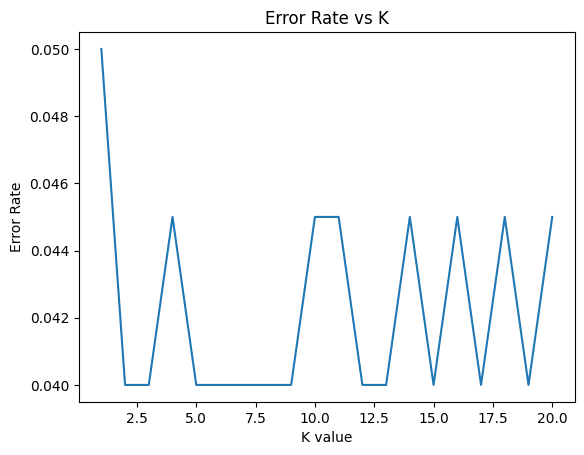

In [ ]:
error = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error.append(np.mean(pred != y_test))

import matplotlib.pyplot as plt
plt.plot(range(1, 21), error)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K")
plt.show()


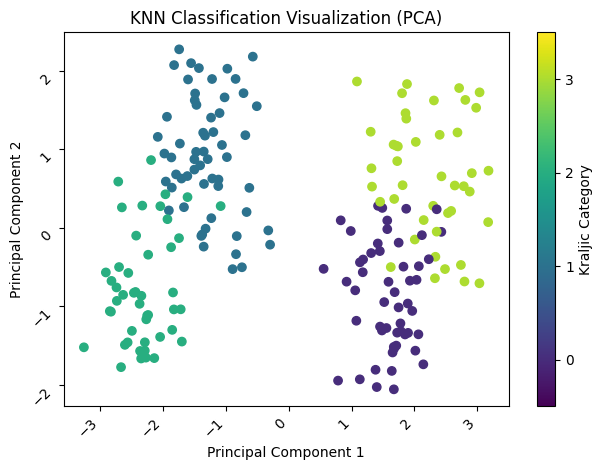

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Encode string labels to numerical values for coloring
label_encoder = LabelEncoder()
y_pred_encoded = label_encoder.fit_transform(y_pred)

plt.figure()
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_encoded, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KNN Classification Visualization (PCA)")
plt.colorbar(ticks=range(len(label_encoder.classes_)), label='Kraljic Category')
plt.clim(-0.5, len(label_encoder.classes_) - 0.5) # Adjust colorbar limits
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, va='top')
plt.tight_layout()
plt.show()


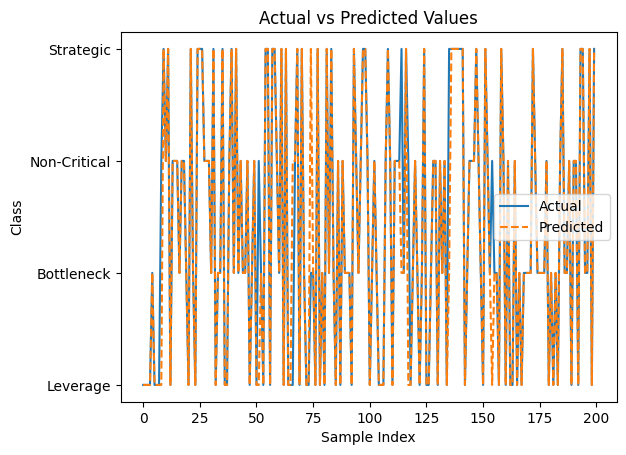

In [ ]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted", linestyle='dashed')
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


In [ ]:
knn_weighted = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

knn_weighted.fit(X_train, y_train)
y_pred_weighted = knn_weighted.predict(X_test)

print("Weighted KNN Accuracy:",
      accuracy_score(y_test, y_pred_weighted))


Weighted KNN Accuracy: 0.955


In [ ]:
metrics = ['euclidean', 'manhattan']

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=m)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    print(f"{m.capitalize()} Accuracy:",
          accuracy_score(y_test, pred))


Euclidean Accuracy: 0.96
Manhattan Accuracy: 0.955


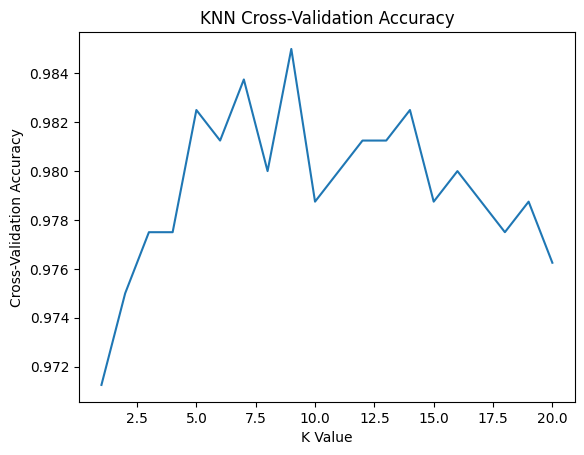

In [ ]:
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

plt.figure()
plt.plot(k_range, cv_scores)
plt.xlabel("K Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("KNN Cross-Validation Accuracy")
plt.show()


**K-Nearest Neighbors (KNN) was applied to the given dataset for classification. The data was first divided into training and testing sets and scaled to ensure accurate distance calculations. Different values of K were tested, and an error-rate vs K plot was used to select the optimal number of neighbors. The trained KNN model was then used to predict class labels for the test data. Visualization techniques like PCA plots helped in understanding class separation. Overall, KNN showed effective performance when an appropriate K value was chosen.**